# Week 9: How Much Should a UHPC Prediction Be Trusted?
## Uncertainty and Calibration for Publication-Held-Out Linear Models

In this notebook, I have explained the complete Week 9 workflow, the leakage controls, the prediction-interval methods, and what these results mean. The primary target is a **90% prediction interval** for 28-day UHPC compressive strength.

## This week's overall Summary

- The required Elastic Net split-conformal interval reaches **94.8% coverage** on 307 rows from 24 unseen test publications. Its mean width is **113.852 MPa**.
- Across the six reliable LOPO publications, split conformal reaches **90.8% micro coverage** and **89.7% macro coverage**, close to the 90% target.
- Native Bayesian Ridge intervals cover only **84.0%** of shared-test rows and **81.2%** of LOPO rows. They are too narrow for publication transfer.
- Raw residual-bootstrap intervals are strongly overconfident: only **64.5% shared-test coverage** and **61.2% LOPO coverage**.
- Conformal correction repairs bootstrap coverage to **95.8% shared** and **90.8% LOPO**, but produces widths similar to ordinary split conformal.
- Split conformal gives the best shared-test Winkler score among the methods that attain the target coverage. It is the preferred primary method for this dataset.

## 1. Research Question

Week 8 showed that row-mixed accuracy overstates transfer to new publications. Week 9 asks the next engineering question:

> When the model predicts a strength for an unseen publication, can its reported uncertainty be trusted?

A useful interval must balance two properties:

1. **Calibration:** a nominal 90% interval should cover approximately 90% of future targets.
2. **Sharpness:** among similarly calibrated methods, narrower intervals are more useful.

A narrow interval with poor coverage is not successful.

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

cwd = Path.cwd().resolve()
if (cwd / 'configs' / 'week09_uncertainty_calibration.yaml').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'configs' / 'week09_uncertainty_calibration.yaml').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError('Open this notebook from S1_Linear or S1_Linear/notebooks.')

TABLES = PROJECT_ROOT / 'reports' / 'tables' / 'week09'
FIGURES = PROJECT_ROOT / 'reports' / 'figures' / 'week09'
METRICS = PROJECT_ROOT / 'results' / 'metrics' / 'week09'
PREDICTIONS = PROJECT_ROOT / 'results' / 'predictions' / 'week09'

def show_figure(name, width=1050):
    display(Image(filename=str(FIGURES / name), width=width))

readiness = pd.read_csv(TABLES / 'week09_input_readiness_audit.csv')
shared_metrics = pd.read_csv(METRICS / 'week09_shared_interval_metrics.csv')
shared_publications = pd.read_csv(TABLES / 'week09_shared_publication_interval_metrics.csv')
shared_predictions = pd.read_csv(PREDICTIONS / 'week09_shared_interval_predictions.csv')
shared_curve = pd.read_csv(TABLES / 'week09_shared_coverage_curve.csv')
shared_quantiles = pd.read_csv(TABLES / 'week09_shared_calibration_quantiles.csv')
shared_confidence = pd.read_csv(TABLES / 'week09_shared_confidence_diagnostics.csv')
shared_overconfident = pd.read_csv(TABLES / 'week09_shared_overconfident_rows.csv')
shared_roles = pd.read_csv(TABLES / 'week09_shared_role_summary.csv')
shared_leakage = pd.read_csv(TABLES / 'week09_shared_leakage_audit.csv')
lopo_summary = pd.read_csv(TABLES / 'week09_lopo_micro_macro_summary.csv')
lopo_publications = pd.read_csv(METRICS / 'week09_lopo_publication_interval_metrics.csv')
lopo_predictions = pd.read_csv(PREDICTIONS / 'week09_lopo_interval_predictions.csv')
lopo_roles = pd.read_csv(TABLES / 'week09_lopo_role_summary.csv')
lopo_leakage = pd.read_csv(TABLES / 'week09_lopo_leakage_audit.csv')
lopo_comparison = pd.read_csv(TABLES / 'week09_lopo_week08_error_calibration_comparison.csv')
print('Week 9 artifacts loaded successfully.')

Week 9 artifacts loaded successfully.


## 2. What Was Reused From Week 8 for this week

For Week 9, we are not creating a new dataset or retuning the point model. Instead we are reusing:

- the 2,048-row semantic-recoded 50% modeling dataset;
- publication lineage kept outside the predictors;
- the shared publication manifest;
- the frozen Elastic Net and Bayesian Ridge settings;
- the 50-row reliable-publication threshold;
- Week 8 publication error and shift diagnostics.

The saved Week 8 Elastic Net itself is **not** reused for calibration because it was fitted on train plus validation. Week 9 rebuilds the frozen pipeline on training publications only, leaving validation publications available for interval calibration.

In [2]:
display(readiness[['check', 'value', 'status', 'detail']])
assert set(readiness['status']) == {'pass'}

,check,value,status,detail
0,week08_config_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
1,week08_split_dir_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
2,week08_modeling_data_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
3,week08_modeling_lineage_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
4,week08_split_manifest_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
5,week08_frozen_config_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
6,week08_lopo_metrics_exists,True,pass,/Users/apple/Brijesh/DE/SoSe2026/Special Proje...
7,train_row_alignment,1434/1434/1434,pass,X/y/lineage row counts
8,calibration_row_alignment,307/307/307,pass,X/y/lineage row counts
9,test_row_alignment,307/307/307,pass,X/y/lineage row counts


## 3. Calibration Leakage Controls

The shared experiment has three disjoint publication roles:

- **Training:** fit imputation, encoding, scaling, and the model.
- **Calibration:** estimate conformal quantiles or interval corrections.
- **Held-out test:** evaluate coverage and width once.

Publication metadata is attached only after prediction for diagnostics. The test target is never used to select a model, tune a parameter, or estimate interval size.

In [3]:
display(shared_roles)
display(shared_leakage)
assert set(shared_leakage['status']) == {'pass'}

,evaluation_fold,role,n_rows,n_publications
0,shared_publication_test,train,1434,115
1,shared_publication_test,calibration,307,25
2,shared_publication_test,heldout,307,24


,evaluation_fold,check,value,status
0,shared_publication_test,train_calibration_publication_overlap,0,pass
1,shared_publication_test,train_heldout_publication_overlap,0,pass
2,shared_publication_test,calibration_heldout_publication_overlap,0,pass
3,shared_publication_test,all_rows_assigned,2048,pass
4,shared_publication_test,assignment_uses_target_values,False,pass


## 4. Interval Metrics

For every method we report:

- **Empirical coverage:** fraction of actual targets between lower and upper bounds.
- **Coverage gap:** empirical coverage minus nominal coverage. Positive is conservative; negative is undercoverage.
- **Mean interval width:** average `upper - lower`.
- **Winkler score:** width plus a strong penalty when the target falls outside the interval. Lower is better.
- **MAE, RMSE, R2, and Bias:** point-prediction quality remains separate from interval quality.

Coverage is evaluated overall and publication by publication. Macro LOPO coverage gives each publication equal weight, while micro coverage gives every row equal weight.

## 5. Uncertainty Methods

### Elastic Net split conformal
Uses absolute validation residuals. For 90% coverage, the finite-sample validation quantile is **56.926 MPa**, giving a constant interval width of **113.852 MPa**.

### Bayesian Ridge native
Uses the Gaussian predictive mean and standard deviation returned by Bayesian Ridge. This interval is adaptive but relies on the model's distribution assumptions.

### Bayesian Ridge conformalized
Calibrates `absolute residual / predictive standard deviation` on validation. It preserves adaptive widths while correcting scale.

### Elastic Net residual bootstrap
Refits Elastic Net to residual-bootstrap pseudo-targets and adds sampled residual noise. Percentile intervals are evaluated both raw and after conformal expansion.

In [4]:
display(shared_quantiles.loc[np.isclose(shared_quantiles['nominal_coverage'], 0.90), [
    'method', 'calibration_score_type', 'n_calibration_rows',
    'finite_sample_rank', 'quantile_level', 'q_hat', 'bootstrap_repetitions'
]].round(4))

,method,calibration_score_type,n_calibration_rows,finite_sample_rank,quantile_level,q_hat,bootstrap_repetitions
2,elastic_net_split_conformal,absolute_validation_residual,307,278.0,0.9055,56.9261,NaN
6,bayesian_ridge_native,gaussian_predictive_z,307,NaN,NaN,1.6449,NaN
10,bayesian_ridge_conformalized,absolute_residual_over_predictive_std,307,278.0,0.9055,2.1226,NaN
16,elastic_net_residual_bootstrap,bootstrap_percentile_bounds,307,NaN,NaN,NaN,300.0
17,elastic_net_bootstrap_conformalized,outside_bootstrap_interval_distance,307,278.0,0.9055,29.1555,NaN


## 6. Shared Publication-Held-Out Results

This is the main Week 9 comparison because all methods use the same 115 training publications, 25 calibration publications, and 24 unseen test publications.

In [5]:
columns = [
    'method', 'EmpiricalCoverage', 'CoverageGap', 'MeanIntervalWidth',
    'MeanWinklerScore', 'MAE', 'RMSE', 'R2', 'Bias',
    'UncertaintyErrorSpearman'
]
display(shared_metrics[columns].sort_values('MeanWinklerScore').round(3))

,method,EmpiricalCoverage,CoverageGap,MeanIntervalWidth,MeanWinklerScore,MAE,RMSE,R2,Bias,UncertaintyErrorSpearman
0,elastic_net_split_conformal,0.948,0.048,113.852,128.682,27.325,31.925,-0.109,4.835,NaN
4,elastic_net_bootstrap_conformalized,0.958,0.058,117.817,130.168,27.325,31.925,-0.109,4.835,0.001
1,bayesian_ridge_native,0.840,-0.060,108.792,146.724,29.076,33.596,-0.228,3.048,0.203
2,bayesian_ridge_conformalized,0.951,0.051,140.388,154.010,29.076,33.596,-0.228,3.048,0.203
3,elastic_net_residual_bootstrap,0.645,-0.255,59.506,154.958,27.325,31.925,-0.109,4.835,0.001


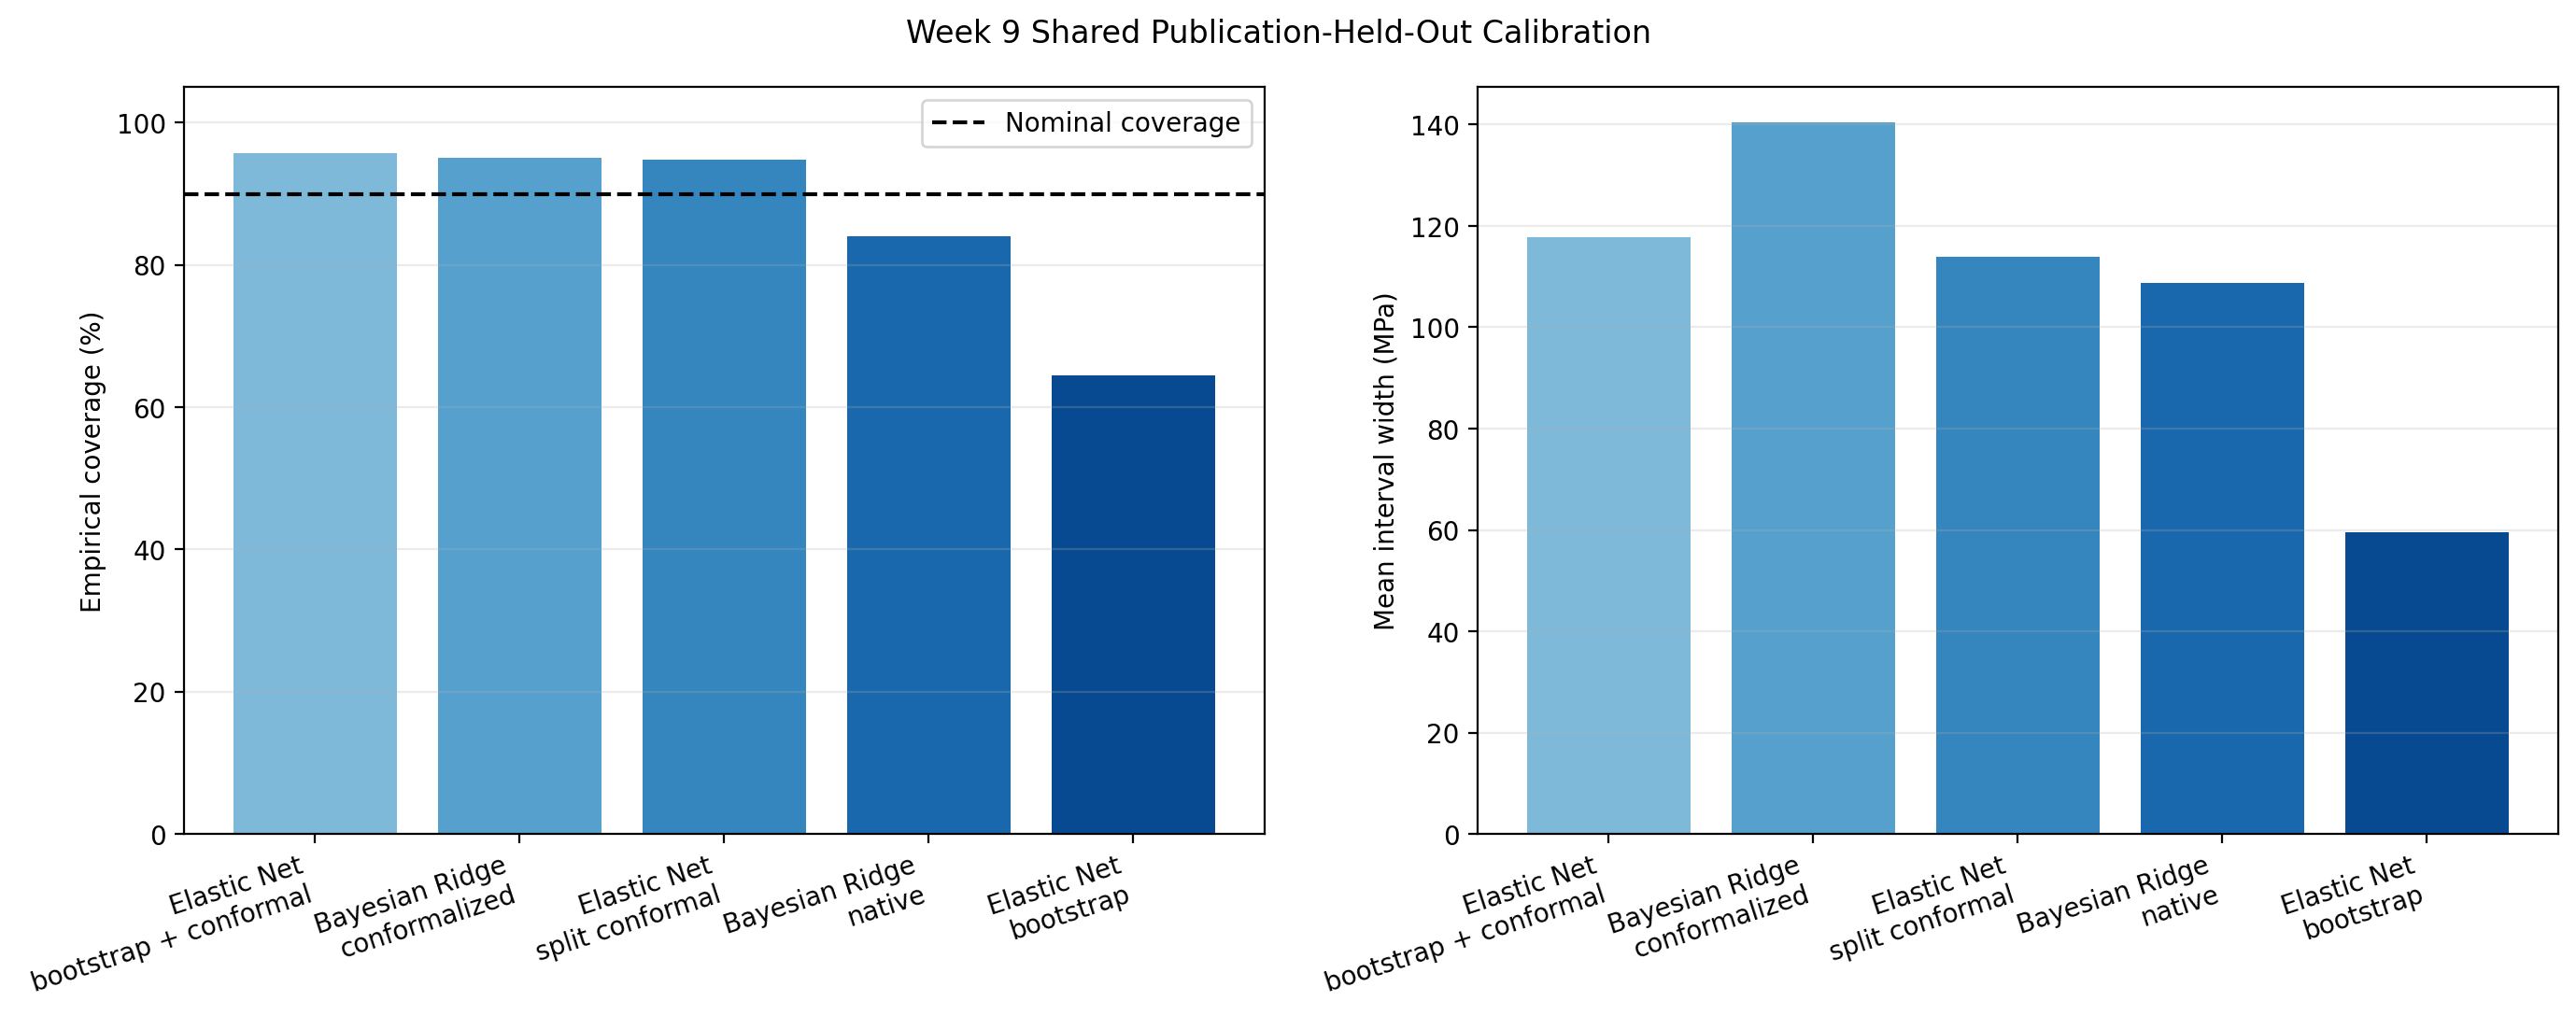

In [6]:
show_figure('week09_method_coverage_width.png', width=1150)

### Shared-result interpretation

- **Split conformal** is conservative by 4.8 percentage points but has the lowest Winkler score among methods that meet the 90% target.
- **Native Bayesian Ridge** misses the target by 6.0 points. Its predictive standard deviation does not fully represent publication shift.
- **Conformalized Bayesian Ridge** repairs coverage but expands mean width to 140.388 MPa, substantially wider than split conformal.
- **Raw residual bootstrap** is severely overconfident. Its 59.506 MPa mean width is attractive only until we notice that it covers just 64.5% of rows.
- **Conformalized bootstrap** repairs coverage, but its width and Winkler score are slightly worse than ordinary split conformal.

Therefore, added method complexity does not produce a better calibrated and sharper primary interval than split conformal.

## 7. Calibration Across Several Nominal Levels

A method can look acceptable at 90% while behaving differently elsewhere. Therefore, I have evaluated 50%, 80%, 90%, and 95% intervals.

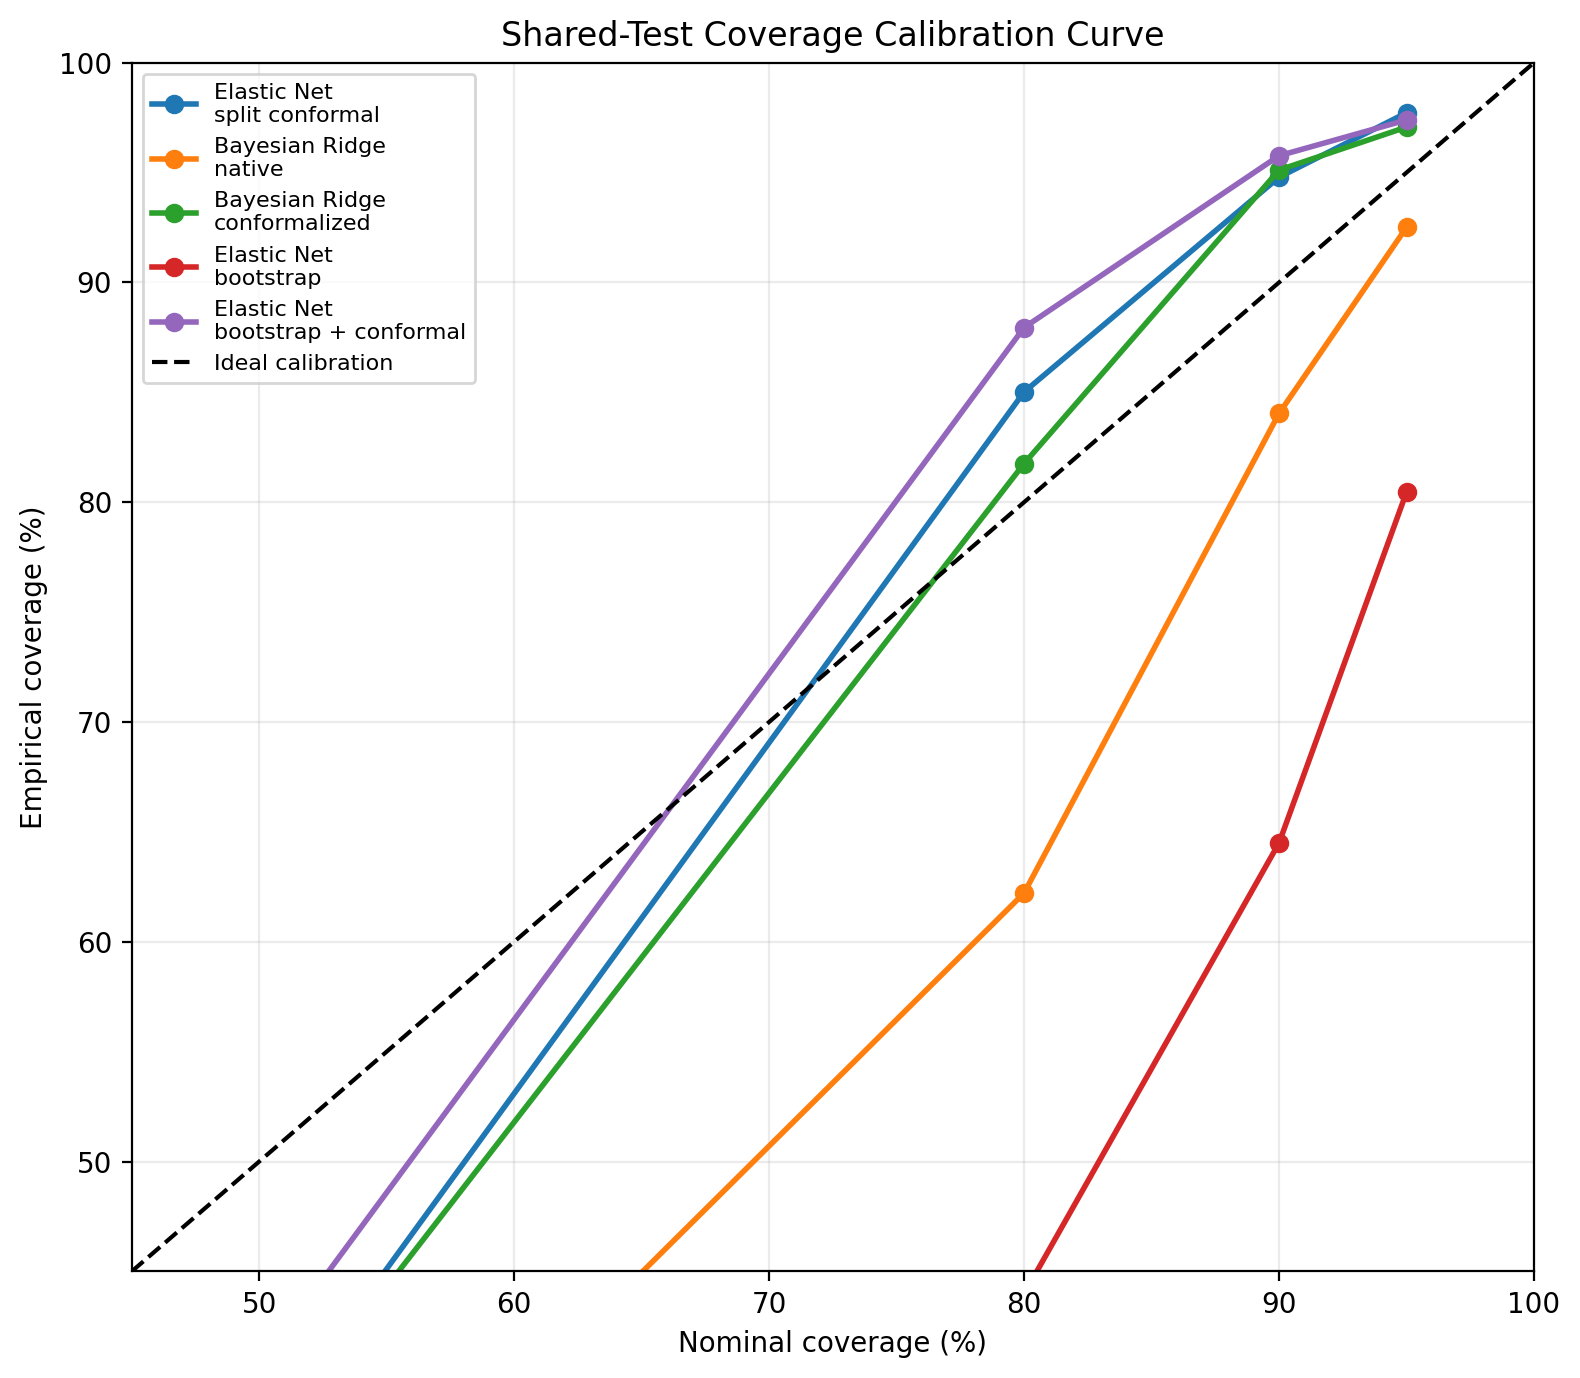

,method,nominal_coverage,EmpiricalCoverage,MeanIntervalWidth
0,elastic_net_split_conformal,0.50,0.371,41.025
1,elastic_net_split_conformal,0.80,0.850,82.123
2,elastic_net_split_conformal,0.90,0.948,113.852
3,elastic_net_split_conformal,0.95,0.977,132.506
4,bayesian_ridge_native,0.50,0.277,44.611
5,bayesian_ridge_native,0.80,0.622,84.763
6,bayesian_ridge_native,0.90,0.840,108.792
7,bayesian_ridge_native,0.95,0.925,129.634
8,bayesian_ridge_conformalized,0.50,0.368,52.816
9,bayesian_ridge_conformalized,0.80,0.818,106.404


In [7]:
show_figure('week09_coverage_curve.png', width=850)
display(shared_curve[['method', 'nominal_coverage', 'EmpiricalCoverage', 'MeanIntervalWidth']].round(3))

### Coverage-curve interpretation

The conformal methods are close to or above target at 80%, 90%, and 95%, but under-cover at 50%. 
It could be possible because validation and test rows come from different publications and are not perfectly exchangeable. The empirical results should be reported honestly rather than claiming a universal finite-sample guarantee under publication shift.

Raw Bayesian and bootstrap intervals remain below the ideal line at most levels, confirming systematic underestimation of uncertainty.

## 8. Which Shared-Test Publications Are Poorly Covered?

Overall coverage can hide entire publications that fail. Publication-level coverage is therefore essential, but row count must be shown because many test publications are small.

,publication_group,n_rows,CoverageEvidence,EmpiricalCoverage,MeanIntervalWidth,RMSE,Bias,ConfidenceDiagnostic
10,Ref-152-Research,2,limited_n_lt_10,0.000,113.852,79.676,79.663,narrow_but_wrong
11,Ref-167-Research,3,limited_n_lt_10,0.000,113.852,76.142,75.266,narrow_but_wrong
20,Ref-111-Research,2,limited_n_lt_10,0.500,113.852,51.915,50.388,narrow_but_wrong
24,Ref-108-Research,3,limited_n_lt_10,0.667,113.852,40.333,-37.687,narrow_but_wrong
31,Ref-154-Research,4,limited_n_lt_10,0.750,113.852,56.844,-43.192,narrow_but_wrong
32,Ref-158-Research,4,limited_n_lt_10,0.750,113.852,51.216,-41.855,narrow_but_wrong
76,Ref-6-Research,24,more_stable_n_ge_10,0.917,113.852,32.818,21.739,well_calibrated_or_sharp
91,Ref-144-Research,110,more_stable_n_ge_10,0.964,113.852,30.357,21.218,well_calibrated_or_sharp
74,Ref-141-Research,71,more_stable_n_ge_10,0.986,113.852,32.832,-31.347,well_calibrated_or_sharp
86,Ref-133-Research,2,limited_n_lt_10,1.000,113.852,4.609,1.356,well_calibrated_or_sharp


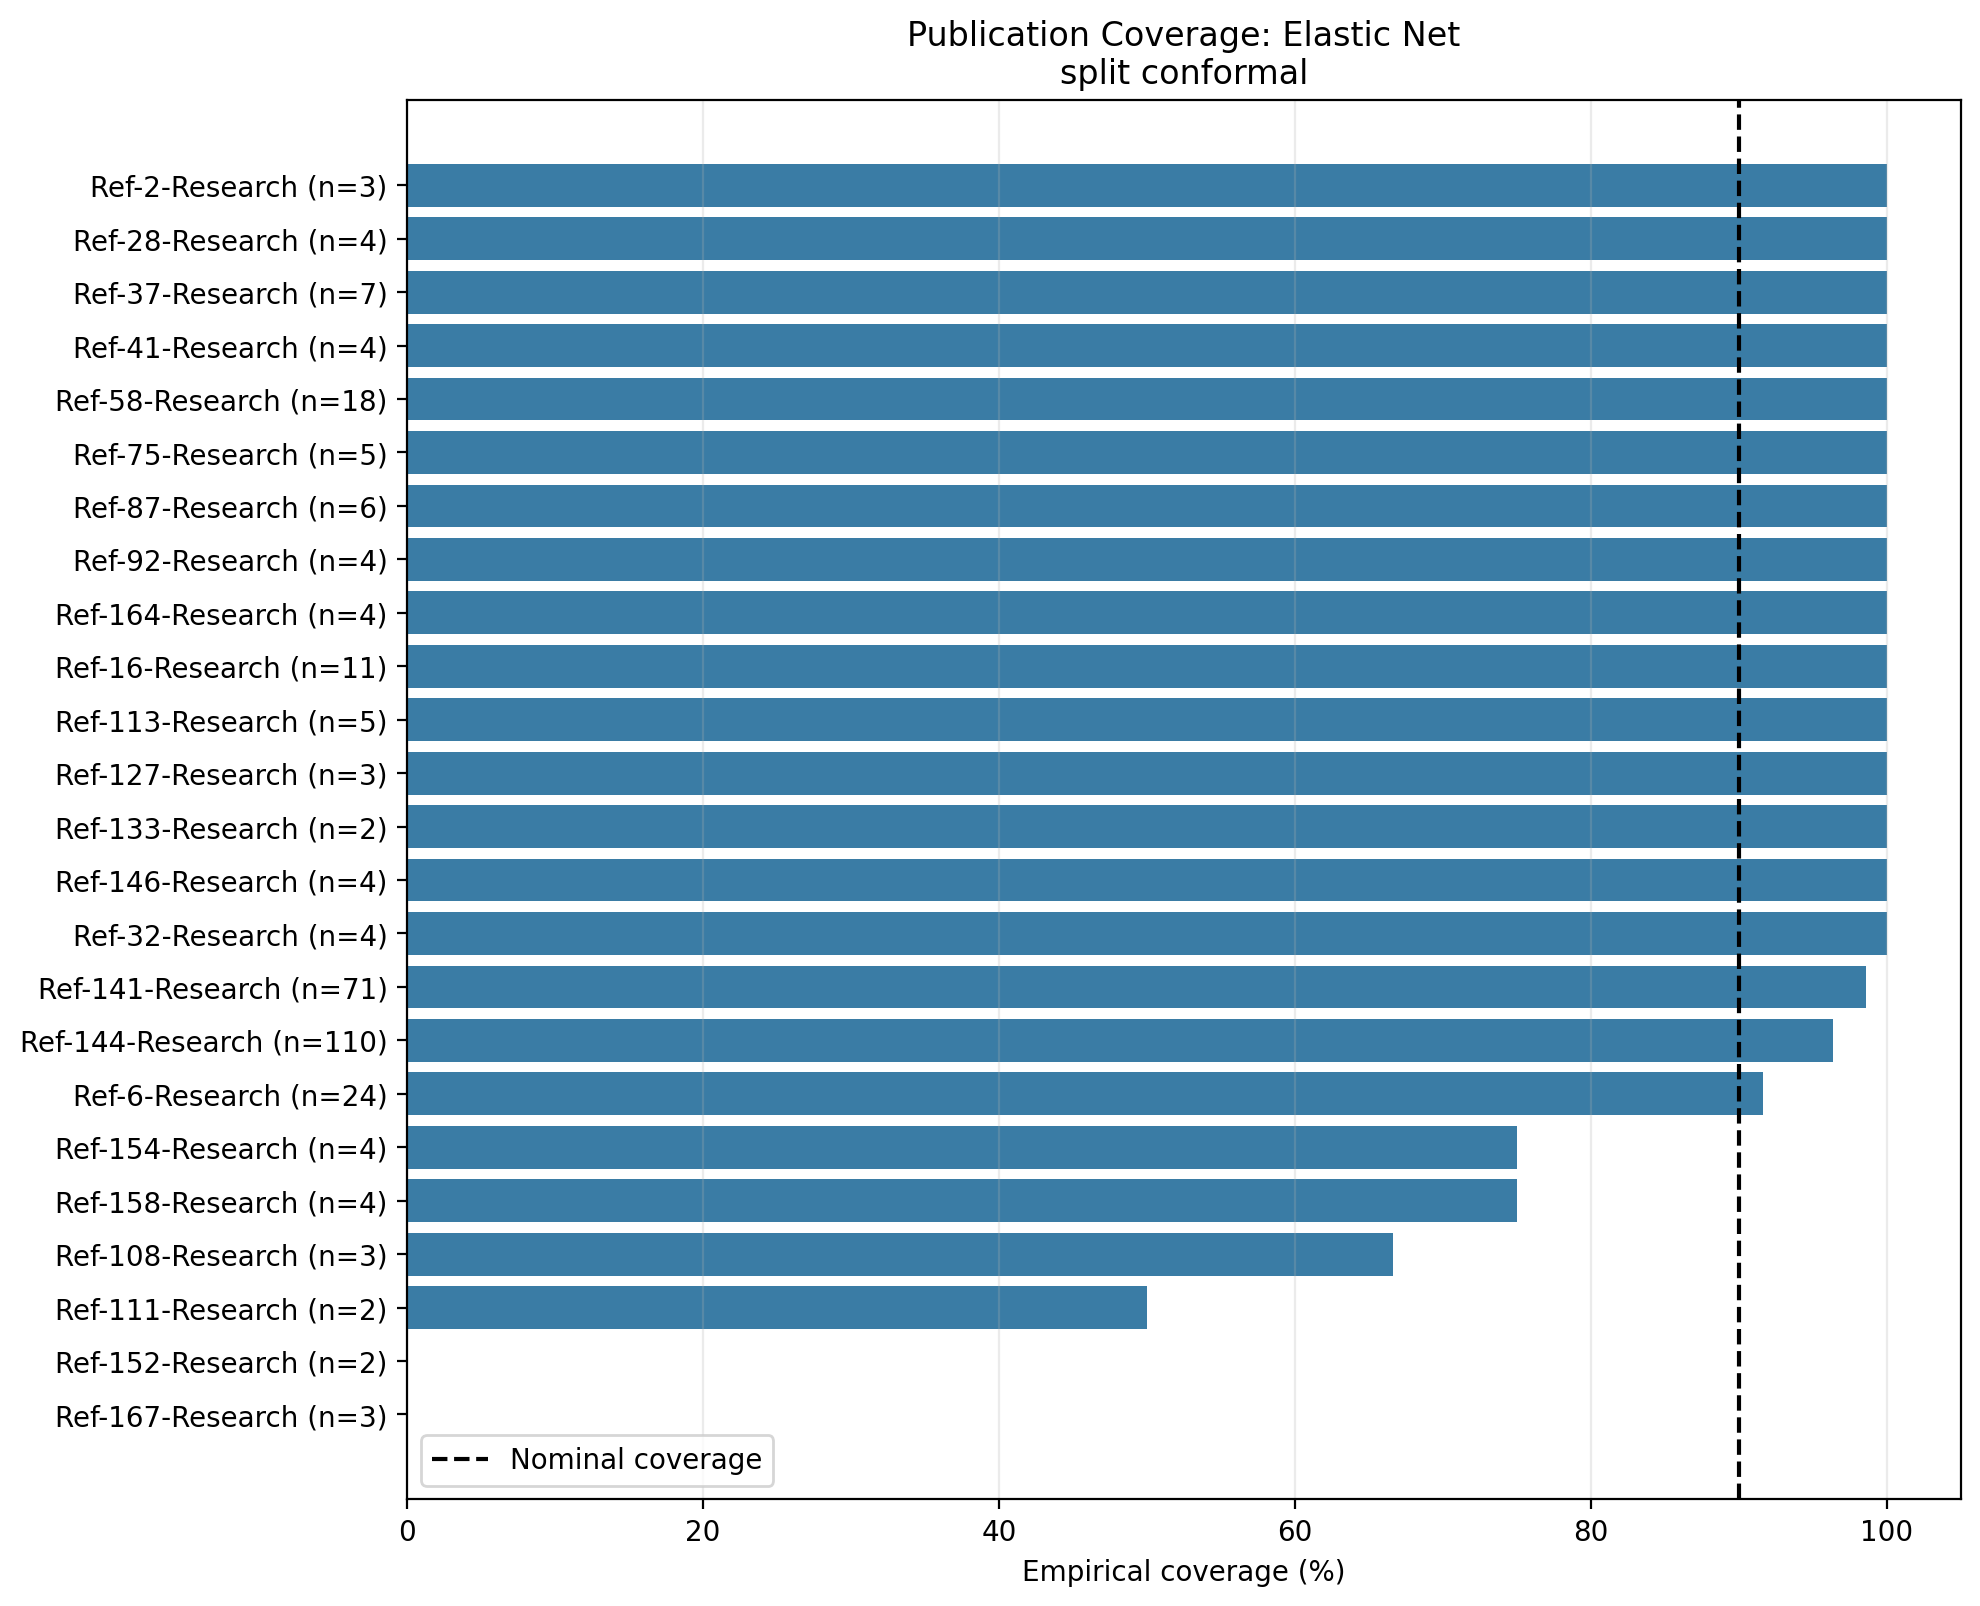

In [8]:
split_conformal_publications = shared_confidence.query(
    "method == 'elastic_net_split_conformal'"
).sort_values(['EmpiricalCoverage', 'n_rows'])
display(split_conformal_publications[[
    'publication_group', 'n_rows', 'CoverageEvidence', 'EmpiricalCoverage',
    'MeanIntervalWidth', 'RMSE', 'Bias', 'ConfidenceDiagnostic'
]].head(12).round(3))
show_figure('week09_publication_coverage.png', width=950)

### Publication interpretation

The lowest shared-test coverages occur for publications with only two to four rows. For example, `Ref-152-Research` and `Ref-167-Research` have zero split-conformal coverage, but each contains only two or three test rows. These are important failure examples, not stable publication-wide estimates.

Larger publications are more informative: `Ref-144-Research` has 110 rows and 96.4% shared-test coverage, while `Ref-141-Research` has 71 rows and 98.6%.

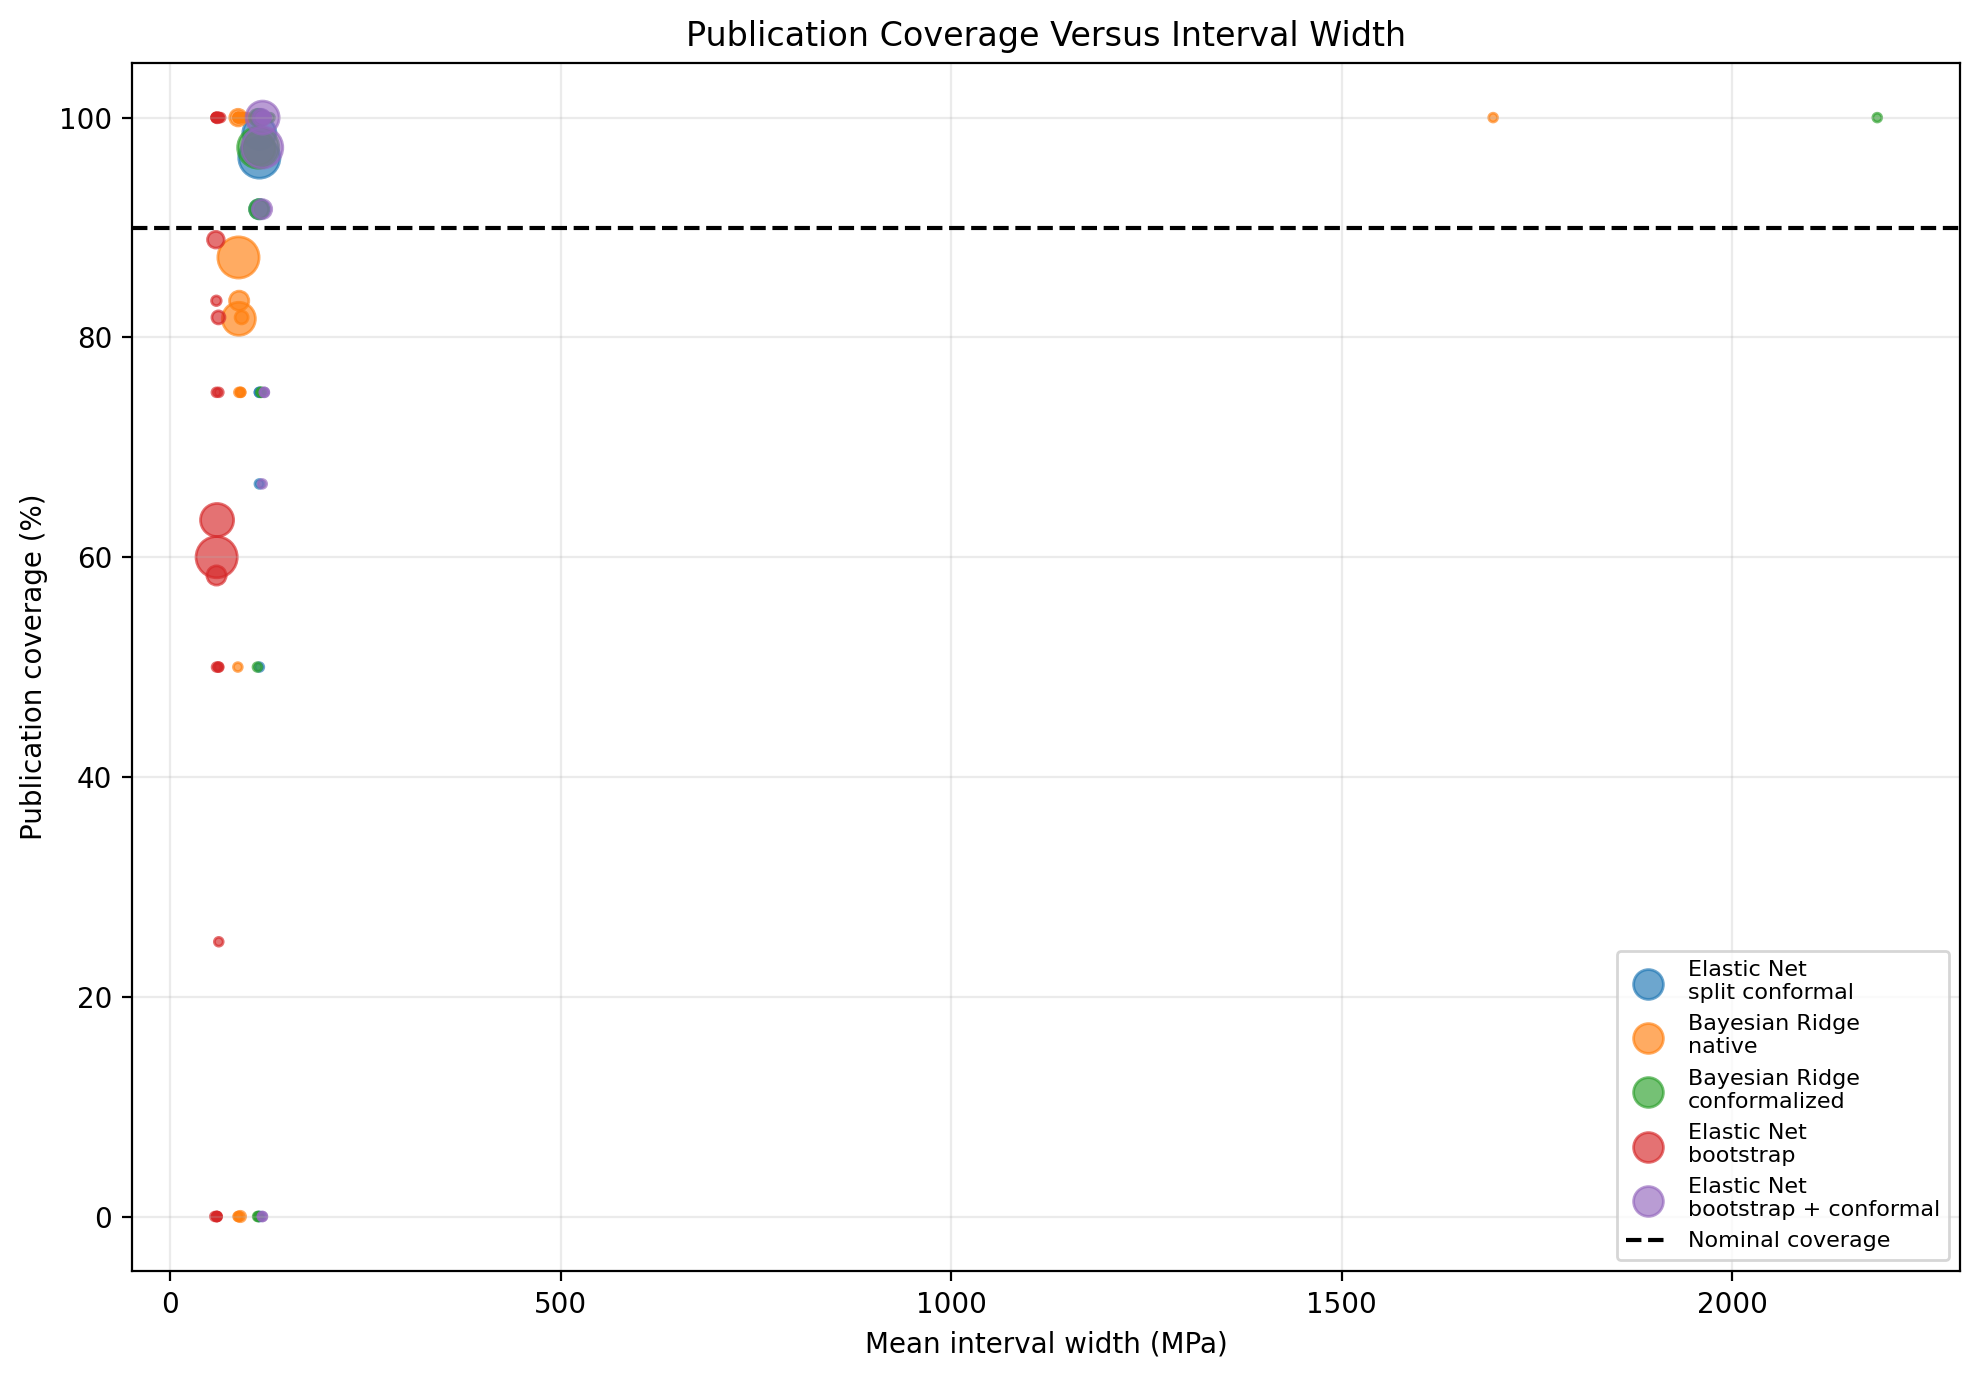

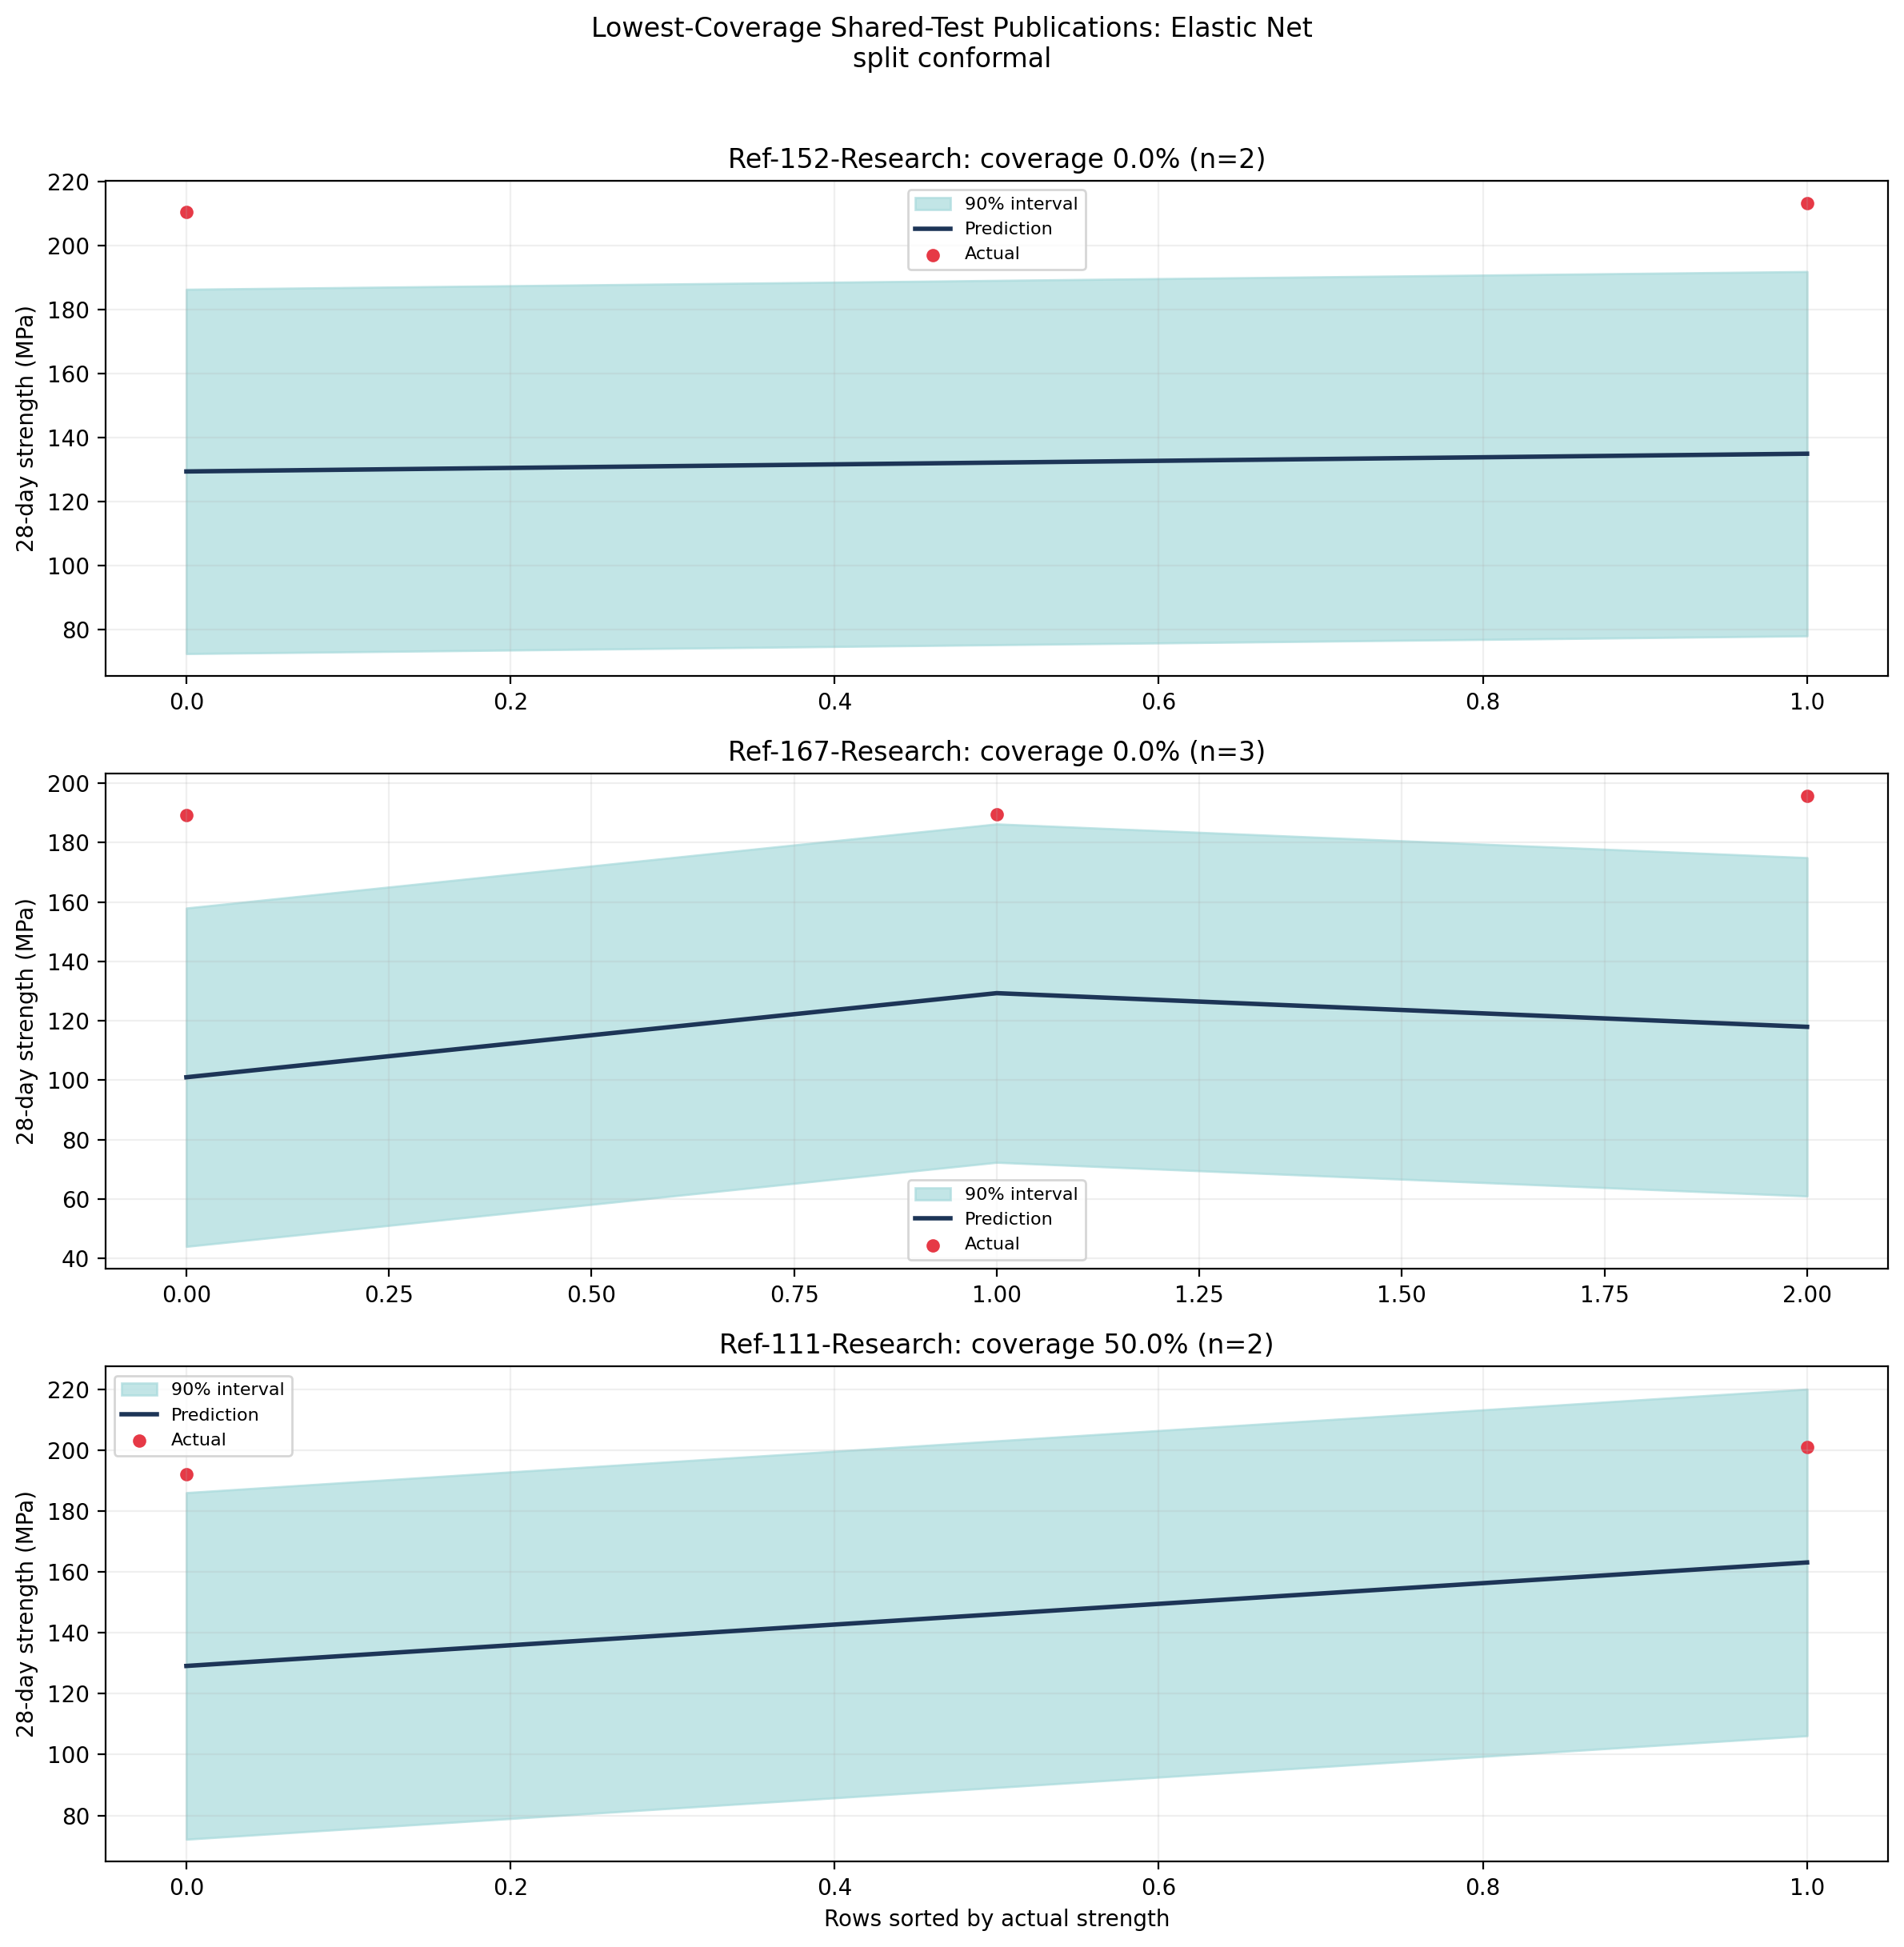

In [9]:
show_figure('week09_coverage_vs_width.png', width=950)
show_figure('week09_shared_interval_examples.png', width=1050)

## 9. Overconfident Rows

Rows outside an interval are overconfident failures. `StandardizedError` divides absolute error by interval half-width, making the most severe narrow misses easy to rank.

In [10]:
display(shared_overconfident[[
    'method', 'publication_group', 'Actual', 'Predicted', 'Lower', 'Upper',
    'AbsoluteError', 'IntervalWidth', 'StandardizedError', 'MissDirection'
]].head(15).round(3))

,method,publication_group,Actual,Predicted,Lower,Upper,AbsoluteError,IntervalWidth,StandardizedError,MissDirection
0,elastic_net_residual_bootstrap,Ref-154-Research,98.000,202.441,170.177,237.082,104.441,66.905,3.122,below_interval_overprediction
1,elastic_net_residual_bootstrap,Ref-167-Research,195.533,117.975,91.879,147.518,77.558,55.639,2.788,above_interval_underprediction
2,elastic_net_residual_bootstrap,Ref-152-Research,213.200,135.010,108.495,165.633,78.190,57.138,2.737,above_interval_underprediction
3,elastic_net_residual_bootstrap,Ref-152-Research,210.600,129.464,102.973,164.385,81.136,61.412,2.642,above_interval_underprediction
4,elastic_net_residual_bootstrap,Ref-167-Research,189.100,101.017,66.232,134.179,88.083,67.946,2.593,above_interval_underprediction
5,elastic_net_residual_bootstrap,Ref-158-Research,114.000,200.760,169.232,238.504,86.760,69.272,2.505,below_interval_overprediction
6,elastic_net_residual_bootstrap,Ref-144-Research,225.000,159.128,130.405,185.296,65.872,54.891,2.400,above_interval_underprediction
7,elastic_net_residual_bootstrap,Ref-144-Research,229.000,157.185,123.751,188.016,71.815,64.264,2.235,above_interval_underprediction
8,elastic_net_residual_bootstrap,Ref-167-Research,189.467,129.310,100.833,155.936,60.157,55.103,2.183,above_interval_underprediction
9,bayesian_ridge_native,Ref-154-Research,98.000,199.526,150.868,248.184,101.526,97.316,2.087,below_interval_overprediction


## 10. Do Adaptive Uncertainty Scores Track Error?

Split conformal has constant width, so it cannot warn that one row is more unfamiliar than another. Bayesian and bootstrap methods provide row-varying uncertainty scores.

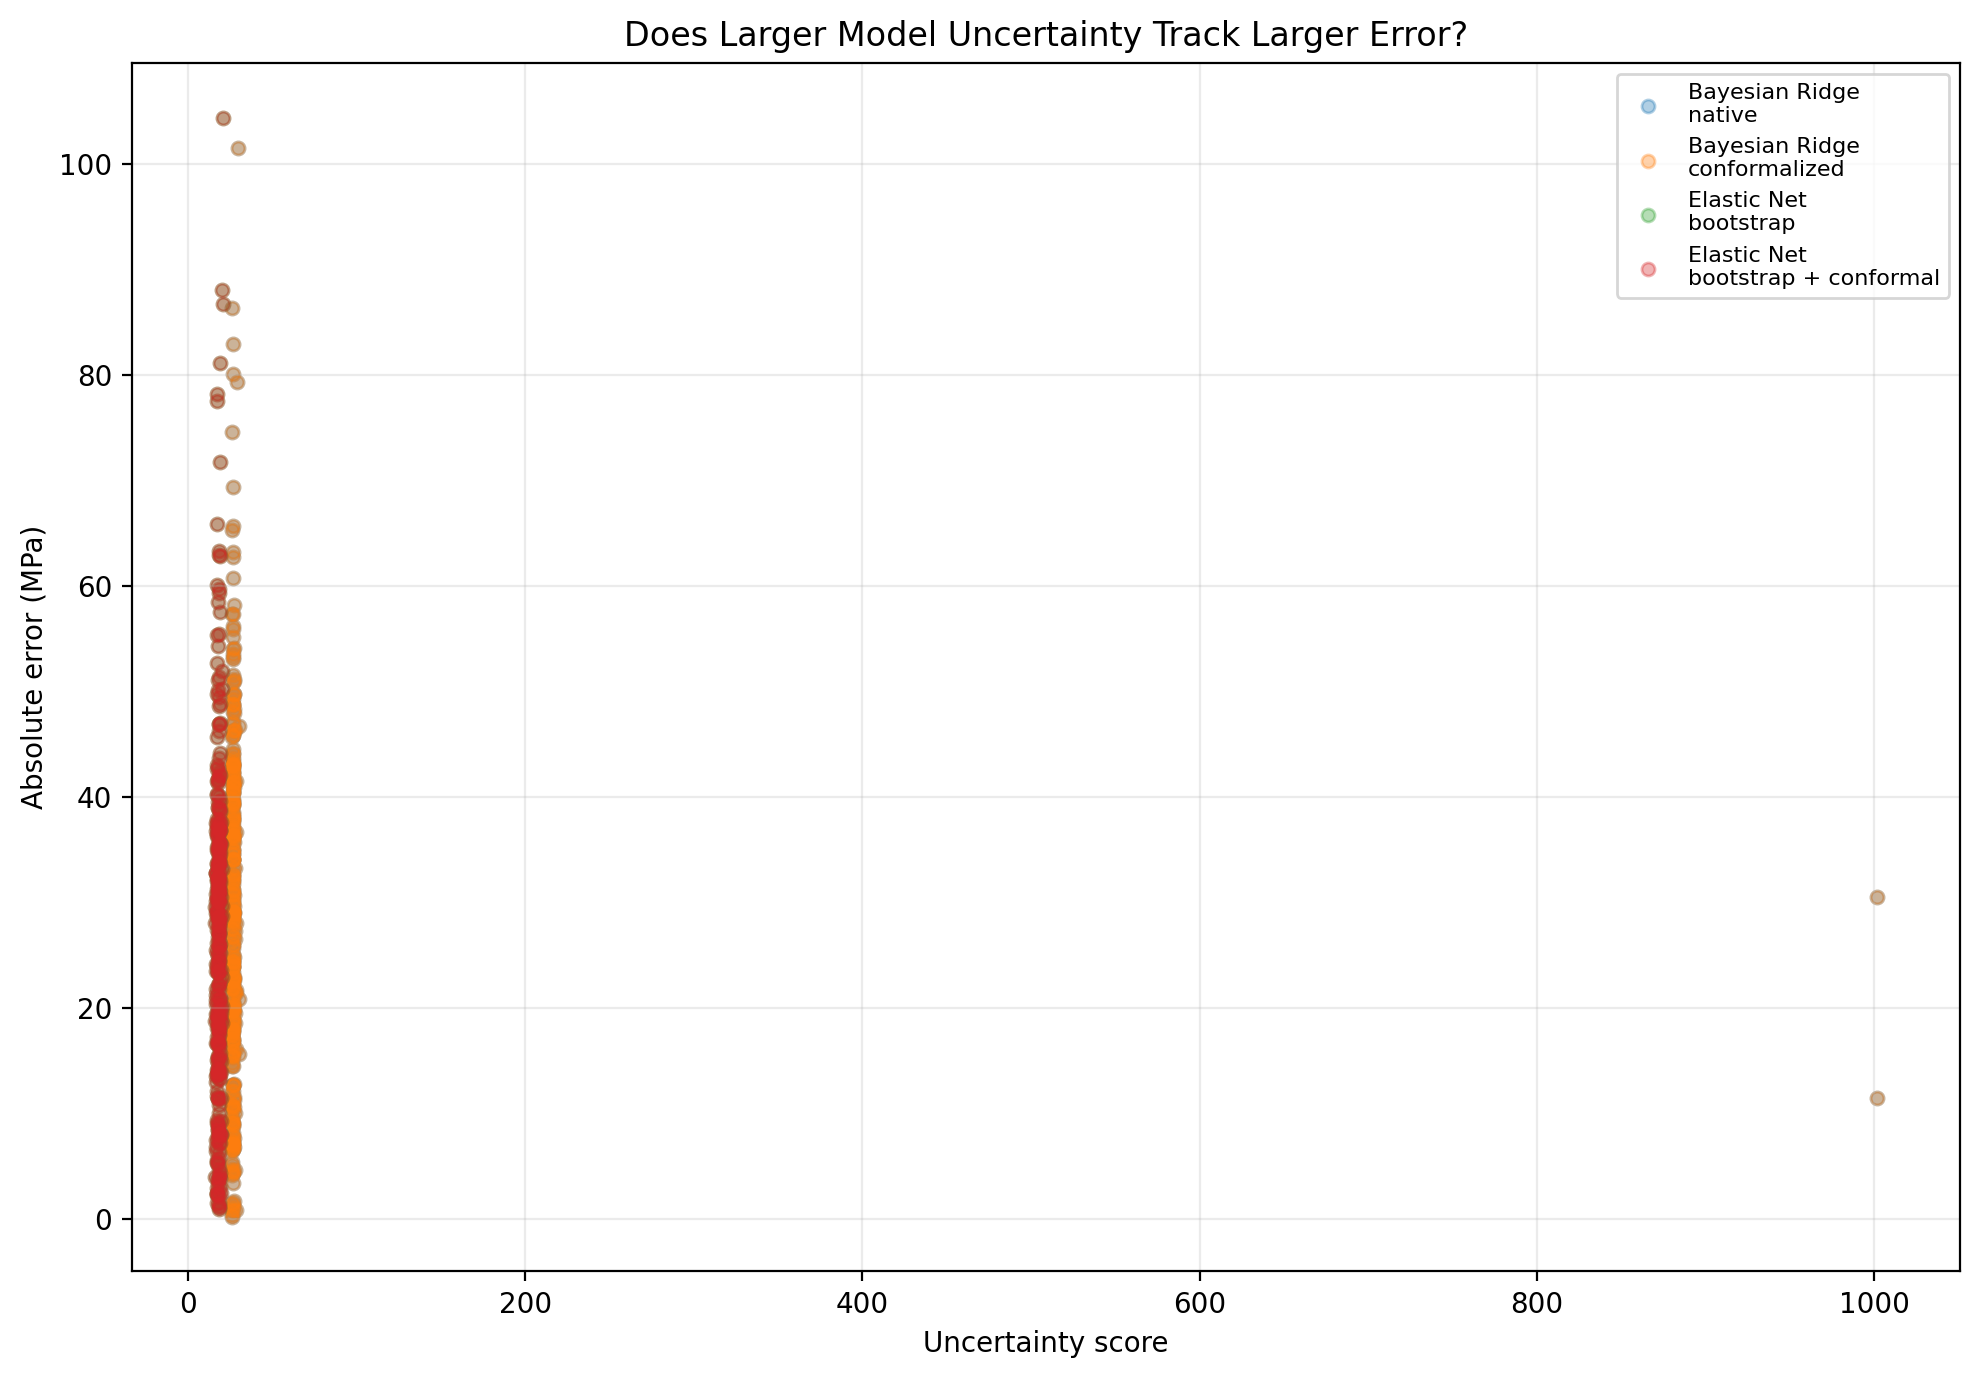

,method,UncertaintyErrorSpearman
0,elastic_net_split_conformal,NaN
1,bayesian_ridge_native,0.203
2,bayesian_ridge_conformalized,0.203
3,elastic_net_residual_bootstrap,0.001
4,elastic_net_bootstrap_conformalized,0.001


In [11]:
show_figure('week09_uncertainty_vs_error.png', width=950)
display(shared_metrics[['method', 'UncertaintyErrorSpearman']].round(3))

### Adaptive-score interpretation

Bayesian width has a weak positive Spearman relationship with absolute error, about **0.203**. Bootstrap width has essentially no relationship, about **0.001**. Constant split-conformal width correctly reports this correlation as unavailable.

The adaptive methods therefore provide only weak row-level unfamiliarity signals. Their varying width should not be treated as a reliable error detector.

## 11. Thresholded Leave-One-Publication-Out Calibration

LOPO is rerun because Week 8 LOPO used all non-held publications for model fitting and had no independent calibration set. Week 9 reserves the fixed Week 8 validation publications for calibration in every fold, removing the held publication from that calibration set when necessary.

Only publications with at least 50 rows are evaluated: six publications and 446 total held-out predictions.

In [12]:
display(lopo_roles)
assert set(lopo_leakage['status']) == {'pass'}
print('LOPO leakage checks:', len(lopo_leakage), 'passed')

,evaluation_fold,role,n_rows,n_publications
0,Ref-144-Research,train,1631,138
1,Ref-144-Research,calibration,307,25
2,Ref-144-Research,heldout,110,1
3,Ref-121-Research,train,1741,139
4,Ref-121-Research,calibration,229,24
5,Ref-121-Research,heldout,78,1
6,Ref-48-Research,train,1669,138
7,Ref-48-Research,calibration,307,25
8,Ref-48-Research,heldout,72,1
9,Ref-141-Research,train,1670,138


LOPO leakage checks: 36 passed


In [13]:
display(lopo_summary[[
    'method', 'aggregation', 'n_publications', 'n_rows',
    'EmpiricalCoverage', 'CoverageGap', 'MeanIntervalWidth',
    'MeanWinklerScore', 'RMSE', 'R2'
]].round(3))

,method,aggregation,n_publications,n_rows,EmpiricalCoverage,CoverageGap,MeanIntervalWidth,MeanWinklerScore,RMSE,R2
0,elastic_net_split_conformal,micro_all_rows,6,446,0.908,0.008,110.632,130.457,33.032,-0.031
1,elastic_net_split_conformal,macro_equal_publication_weight,6,446,0.897,-0.003,110.270,132.237,33.300,-1.732
2,bayesian_ridge_native,micro_all_rows,6,446,0.812,-0.088,87.703,136.769,33.466,-0.058
3,bayesian_ridge_native,macro_equal_publication_weight,6,446,0.793,-0.107,87.823,142.366,33.463,-2.120
4,bayesian_ridge_conformalized,micro_all_rows,6,446,0.906,0.006,111.494,132.022,33.466,-0.058
5,bayesian_ridge_conformalized,macro_equal_publication_weight,6,446,0.894,-0.006,111.159,133.972,33.463,-2.120
6,elastic_net_residual_bootstrap,micro_all_rows,6,446,0.612,-0.288,61.856,175.005,33.032,-0.031
7,elastic_net_residual_bootstrap,macro_equal_publication_weight,6,446,0.590,-0.310,61.926,185.547,33.300,-1.732
8,elastic_net_bootstrap_conformalized,micro_all_rows,6,446,0.908,0.008,110.822,130.201,33.032,-0.031
9,elastic_net_bootstrap_conformalized,macro_equal_publication_weight,6,446,0.898,-0.002,110.412,132.060,33.300,-1.732


### LOPO interpretation

- Elastic Net split conformal reaches **90.8% micro coverage** and **89.7% macro coverage**, the closest result to the requested 90% behavior.
- Bayesian conformal coverage is similar, but its point RMSE and Winkler score are slightly worse.
- Raw Bayesian coverage is only 81.2%; raw bootstrap coverage is only 61.2%.
- Conformalized bootstrap again repairs coverage, but does not materially improve sharpness over simple split conformal.

The agreement between micro and macro split-conformal coverage is important: the overall result is not produced only by the largest publication.

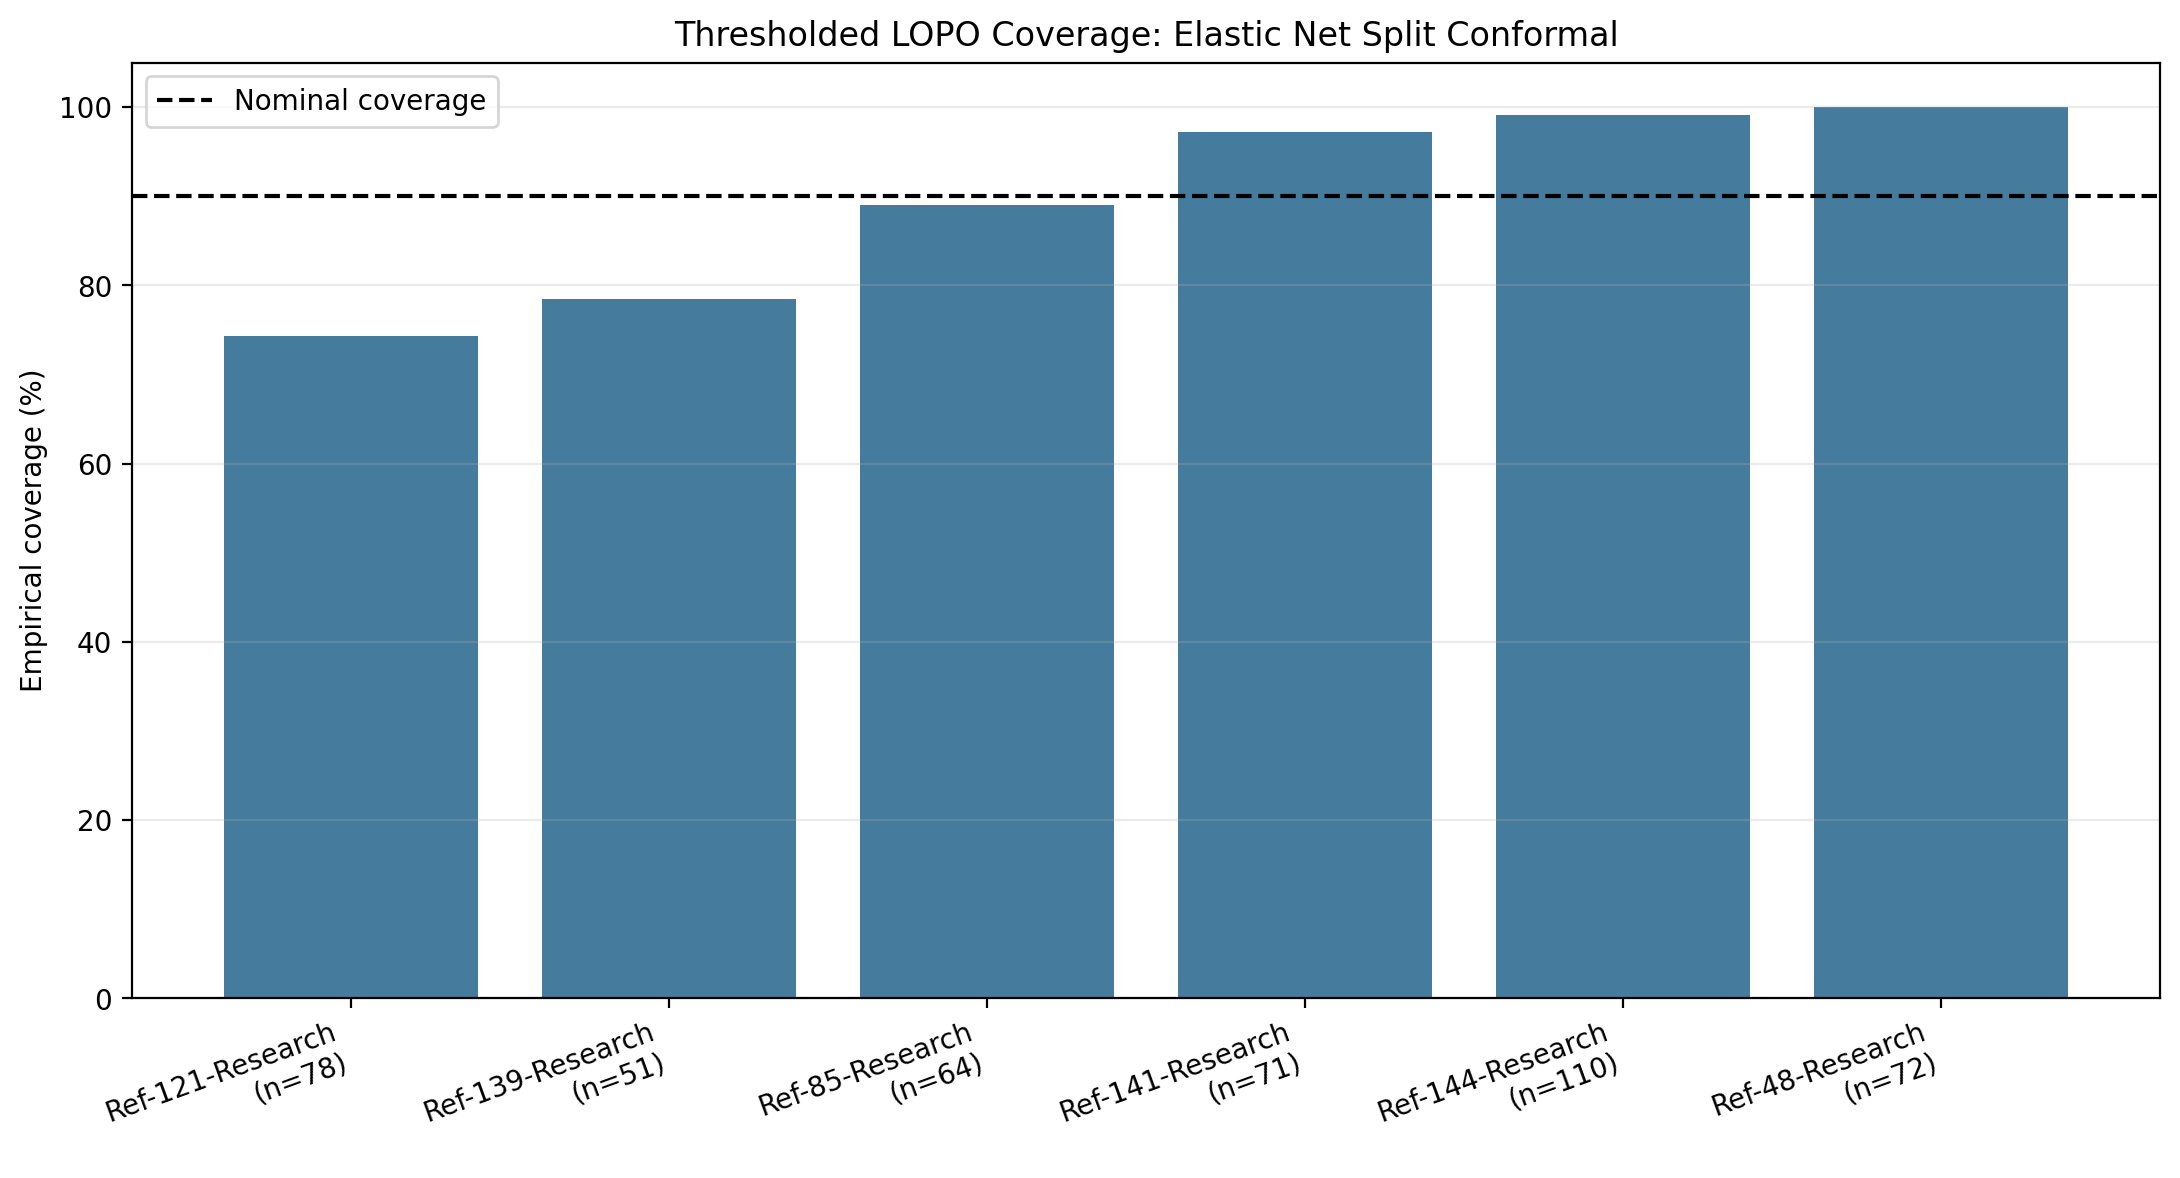

,publication_group,n_rows,EmpiricalCoverage,MeanIntervalWidth,MeanWinklerScore,RMSE,Bias
5,Ref-121-Research,78,0.744,104.738,174.572,41.549,-28.985
25,Ref-139-Research,51,0.784,108.864,155.075,38.146,-28.291
20,Ref-85-Research,64,0.891,108.657,121.317,36.160,32.266
15,Ref-141-Research,71,0.972,111.399,114.299,35.208,-33.876
0,Ref-144-Research,110,0.991,114.311,114.511,23.132,10.048
10,Ref-48-Research,72,1.000,113.649,113.649,25.608,12.225


In [14]:
show_figure('week09_lopo_coverage.png', width=1000)
display(lopo_publications.query("method == 'elastic_net_split_conformal'")[[
    'publication_group', 'n_rows', 'EmpiricalCoverage', 'MeanIntervalWidth',
    'MeanWinklerScore', 'RMSE', 'Bias'
]].sort_values('EmpiricalCoverage').round(3))

## 12. Which Reliable LOPO Publications Remain Overconfident?

For split conformal, `Ref-121-Research` has only **74.4% coverage**, and `Ref-139-Research` has **78.4% coverage**. Both are systematically overpredicted, with negative Bias near -29 MPa.

The other four reliable publications are near or above target. This reveals an important limitation of marginal conformal calibration: good overall coverage does not guarantee good conditional coverage for every publication.

,method,publication_group,n_rows,EmpiricalCoverage,MeanIntervalWidth,MeanWinklerScore,Week08PointRMSE,Week08PointBias,numeric_out_of_training_range_rate,unseen_category_rate
7,bayesian_ridge_conformalized,Ref-121-Research,78,0.756,105.631,171.079,40.805,-28.997,0.000,0.000
27,bayesian_ridge_conformalized,Ref-139-Research,51,0.804,108.131,154.986,33.627,-24.218,0.010,0.004
22,bayesian_ridge_conformalized,Ref-85-Research,64,0.891,108.455,120.713,36.938,32.155,0.000,0.000
17,bayesian_ridge_conformalized,Ref-141-Research,71,0.930,108.501,119.399,47.139,-45.996,0.000,0.000
12,bayesian_ridge_conformalized,Ref-48-Research,72,0.986,122.579,124.001,29.879,17.229,0.000,0.093
2,bayesian_ridge_conformalized,Ref-144-Research,110,1.000,113.656,113.656,21.263,4.611,0.008,0.000
5,elastic_net_split_conformal,Ref-121-Research,78,0.744,104.738,174.572,40.805,-28.997,0.000,0.000
25,elastic_net_split_conformal,Ref-139-Research,51,0.784,108.864,155.075,33.627,-24.218,0.010,0.004
20,elastic_net_split_conformal,Ref-85-Research,64,0.891,108.657,121.317,36.938,32.155,0.000,0.000
15,elastic_net_split_conformal,Ref-141-Research,71,0.972,111.399,114.299,47.139,-45.996,0.000,0.000


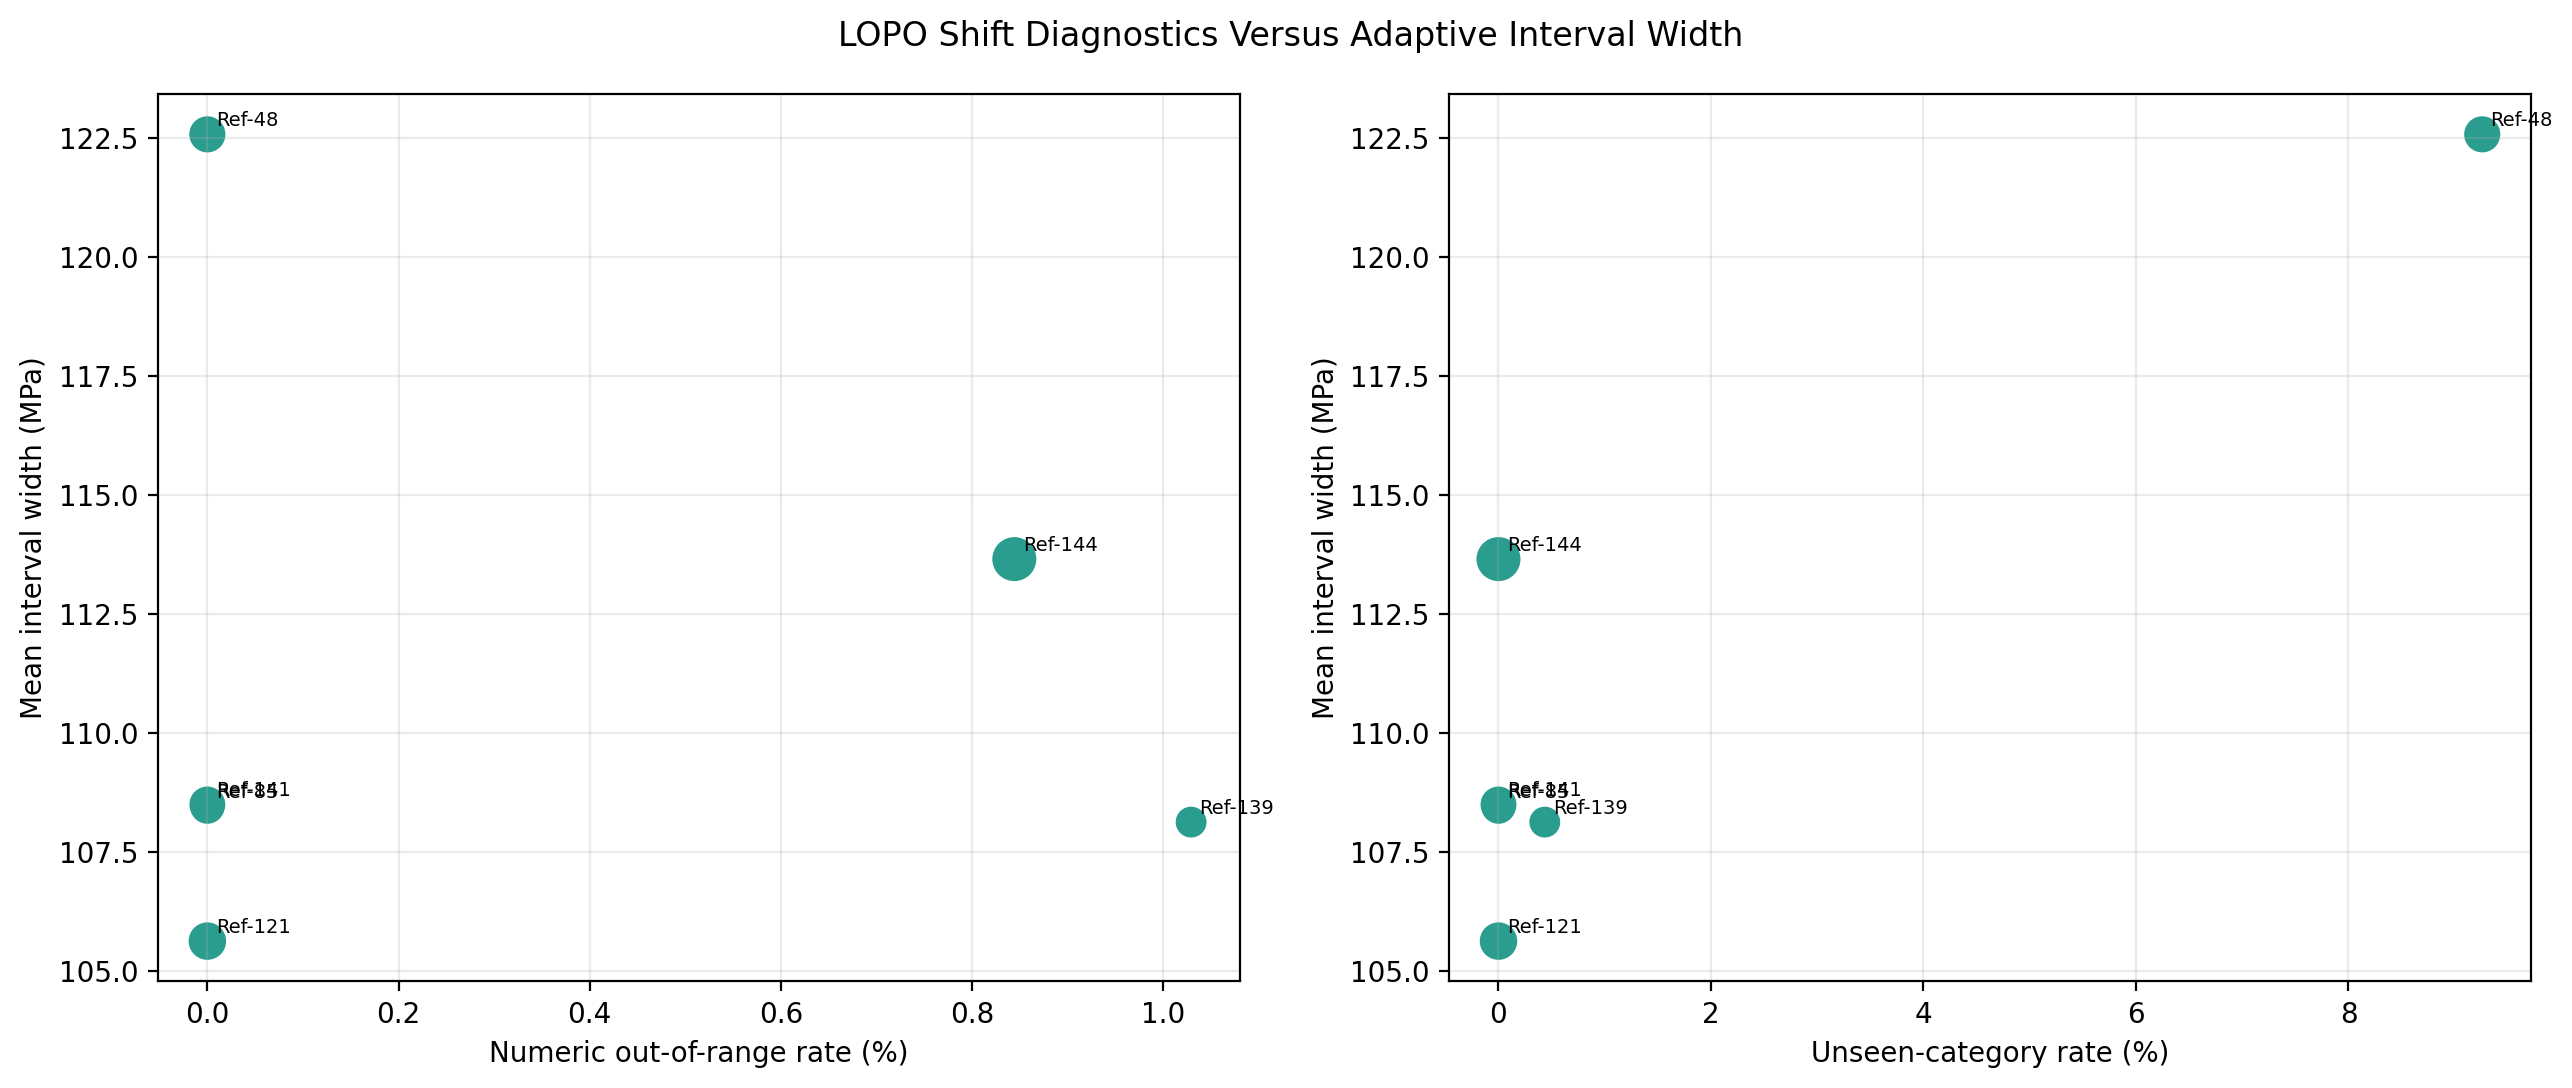

In [15]:
comparison_columns = [
    'method', 'publication_group', 'n_rows', 'EmpiricalCoverage',
    'MeanIntervalWidth', 'MeanWinklerScore', 'Week08PointRMSE',
    'Week08PointBias', 'numeric_out_of_training_range_rate',
    'unseen_category_rate'
]
display(lopo_comparison.query(
    "method in ['elastic_net_split_conformal', 'bayesian_ridge_conformalized']"
)[comparison_columns].sort_values(['method', 'EmpiricalCoverage']).round(3))
show_figure('week09_lopo_shift_vs_uncertainty.png', width=1050)

### Shift interpretation

Simple numeric out-of-range and unseen-category rates still do not explain the main failures. `Ref-121-Research` has zero values outside the training range and no unseen categories, yet its coverage is poor.

The problem is likely publication-level calibration shift hidden inside familiar feature ranges: laboratory procedures, material chemistry, specimen geometry, testing setup, or semantic harmonization differences.

<!-- ## 15. Recommended Improvements

1. Test a fresh publication-level calibration subset carved only from Week 8 training publications.
2. Investigate group-aware or publication-balanced conformal calibration.
3. Add richer specimen, testing, curing-history, and material-source metadata.
4. Develop uncertainty scores based on distance in the transformed feature space and validate them against residual size.
5. Highlight `Ref-121-Research`, `Ref-139-Research`, and the largest standardized row misses in later explainability work. -->

<!-- ## 16. Presentation Talking Points

- Week 8 asked whether the point model transfers; Week 9 asks whether its uncertainty can be trusted.
- Training, calibration, and test publications are completely separate.
- A 90% Elastic Net conformal interval covers 94.8% of shared-test rows and 90.8% of reliable LOPO rows.
- Raw bootstrap intervals look impressively narrow but cover only 64.5%, making them unsafe.
- Bayesian conformalization repairs coverage but is much wider than split conformal.
- Good overall coverage still hides publication-specific failures, especially `Ref-121` and `Ref-139`. -->

<!-- ## 17. Reproduce the Workflow

Run from `S1_Linear/`:

```bash
PYTHONPATH=src .venv/bin/python -m s1_linear.week09.runner
```

The runner rebuilds all train-only models, 300-repetition bootstrap distributions, shared-test intervals, six LOPO folds, tables, model artifacts, and figures. -->